# WikiNews NLP Project — Exploratory Data Analysis

This notebook explores the WikiNews dataset and prepares the analytical subsets used in the project.

The main goals are to:

- inspect the dataset structure,
- understand language distribution,
- analyse the four selected news categories,
- inspect article lengths,
- identify category imbalance and overlap,
- validate the final analysis and classification datasets.

In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import (
    SELECTED_CATEGORIES,
    filter_analysis_candidates,
    filter_by_language,
    filter_exclusive_categories,
    load_jsonl,
    prepare_wikinews_dataframe,
)

In [18]:
RAW_DATA_PATH = PROJECT_ROOT / "data/raw/multilingual_wikinews.jsonl"

df = load_jsonl(RAW_DATA_PATH)
df = prepare_wikinews_dataframe(df)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (15200, 11)


,title,pageid,categories,lang,url,text,date,type,word_count,sentence_count,category_count
0,'Bloody Sunday Inquiry' publishes report into ...,191513,"[Northern Ireland, Martin McGuinness, Politics...",en,https://en.wikinews.org/wiki/%27Bloody_Sunday_...,"On Tuesday, the ""Bloody Sunday Inquiry"" publis...",2010-06-17,title,520,19,11
1,1972 ”இரத்த ஞாயிறு” படுகொலைகள் தொடர்பில் பிரித...,191513,"[Northern Ireland, Martin McGuinness, Politics...",ta,https://ta.wikinews.org/wiki/1972_%E2%80%9D%E0...,வடக்கு அயர்லாந்தில் 38 ஆண்டுகளுக்கு முன்னர் இட...,NaT,interlang link,230,15,11
2,'Very serious': Chinese government releases co...,232226,"[China, December 30, 2010, Politics and confli...",en,https://en.wikinews.org/wiki/%27Very_serious%2...,A report by the Chinese government states corr...,2010-12-30,title,239,10,6
3,"Čína připustila, že tamní korupce je vážný pro...",232226,"[China, December 30, 2010, Politics and confli...",cs,https://cs.wikinews.org/wiki/%C4%8C%C3%ADna_p%...,"Zpráva čínské vlády připouští, že korupce v ze...",NaT,interlang link,208,14,6
4,China admite que la corrupción en el país es '...,232226,"[China, December 30, 2010, Politics and confli...",es,https://es.wikinews.org/wiki/China_admite_que_...,"29 de diciembre de 2010Beijing, China — Un rep...",NaT,interlang link,266,12,6


In [19]:
df.info()
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 15200 entries, 0 to 15199
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   title           15200 non-null  str           
 1   pageid          15200 non-null  int64         
 2   categories      15200 non-null  object        
 3   lang            15200 non-null  str           
 4   url             15200 non-null  str           
 5   text            15200 non-null  str           
 6   date            5225 non-null   datetime64[us]
 7   type            15200 non-null  str           
 8   word_count      15200 non-null  int64         
 9   sentence_count  15200 non-null  int64         
 10  category_count  15200 non-null  int64         
dtypes: datetime64[us](1), int64(4), object(1), str(5)
memory usage: 1.3+ MB
Columns:
['title', 'pageid', 'categories', 'lang', 'url', 'text', 'date', 'type', 'word_count', 'sentence_count', 'category_count']

Missing values:


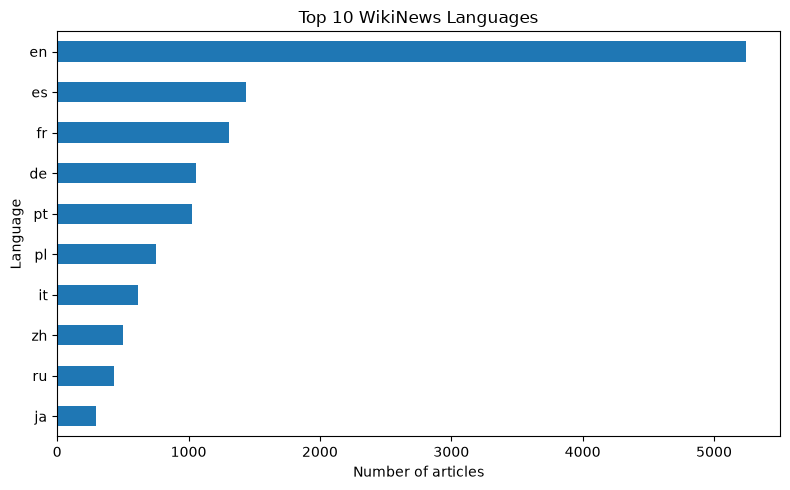

In [20]:
language_counts = df["lang"].value_counts().head(10)

language_counts
language_counts.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Top 10 WikiNews Languages",
)

plt.xlabel("Number of articles")
plt.ylabel("Language")
plt.tight_layout()
plt.show()

In [21]:
english_df = filter_by_language(df, "en")

print("English articles:", len(english_df))

English articles: 5240


## 5. Selected News Categories

The project focuses on four business-relevant news categories:

- Politics and conflicts
- Economy and business
- Science and technology
- Sports

In [22]:
category_counts = {}

for category in SELECTED_CATEGORIES:
    category_counts[category] = english_df["categories"].apply(
        lambda categories: category in categories
    ).sum()

category_counts = pd.Series(category_counts).sort_values()

category_counts

Sports                     455
Economy and business       460
Science and technology     674
Politics and conflicts    2198
dtype: int64

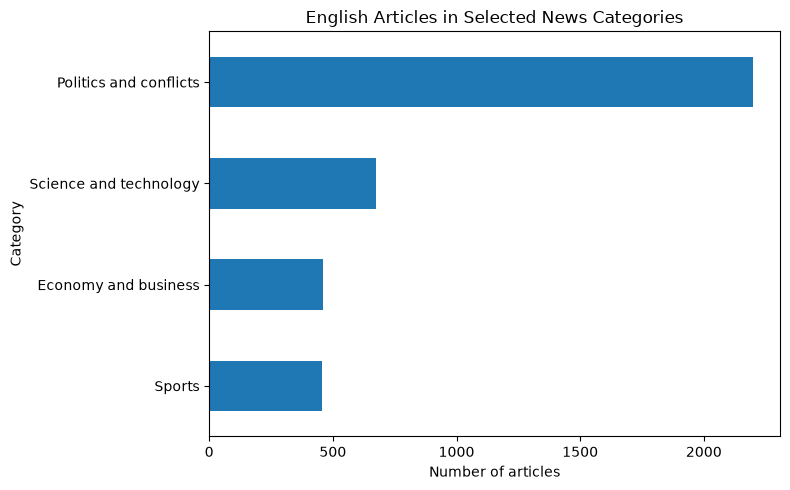

In [23]:
category_counts.plot(
    kind="barh",
    figsize=(8, 5),
    title="English Articles in Selected News Categories",
)

plt.xlabel("Number of articles")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## 6. Exclusive Single-Label Categories

Some WikiNews articles belong to more than one selected category. For cleaner topic classification, only articles belonging to exactly one selected category are retained.

In [24]:
exclusive_df = filter_exclusive_categories(
    english_df,
    SELECTED_CATEGORIES,
)

print("Exclusive-category articles:", len(exclusive_df))

exclusive_df["primary_category"].value_counts()

Exclusive-category articles: 3261


primary_category
Politics and conflicts    2039
Science and technology     527
Sports                     434
Economy and business       261
Name: count, dtype: int64

## 7. Article Length Analysis

Article lengths are analysed to identify unusually short articles and extreme long-form outliers before detailed NLP processing.

In [25]:
exclusive_df["word_count"].describe()

count    3261.000000
mean      327.642134
std       413.679541
min         7.000000
25%       179.000000
50%       252.000000
75%       367.000000
max      9955.000000
Name: word_count, dtype: float64

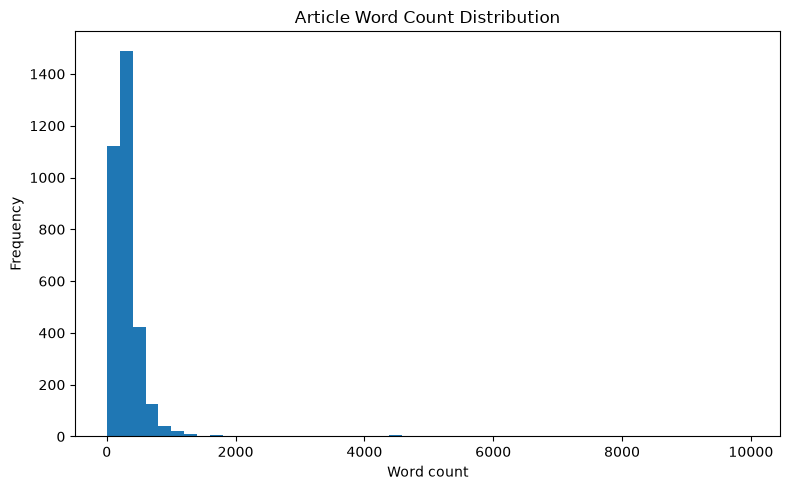

In [26]:
exclusive_df["word_count"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 5),
    title="Article Word Count Distribution",
)

plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [27]:
exclusive_df.groupby(
    "primary_category"
)["word_count"].describe()[
    ["count", "mean", "50%", "min", "max"]
].round(1)

,count,mean,50%,min,max
primary_category,,,,,
Economy and business,261.0,267.3,226.0,57.0,1279.0
Politics and conflicts,2039.0,334.1,258.0,7.0,9955.0
Science and technology,527.0,371.3,253.0,38.0,8305.0
Sports,434.0,280.3,241.5,16.0,1245.0


## 8. Analysis Candidate Filtering

For detailed NER, summarization, and semantic similarity analysis, articles are restricted to:

- valid publication dates,
- non-empty text,
- 100 to 3000 words,
- exactly one selected news category.

In [28]:
analysis_candidates = filter_analysis_candidates(
    exclusive_df
)

print("Analysis candidates:", len(analysis_candidates))

analysis_candidates["primary_category"].value_counts()

Analysis candidates: 3138


primary_category
Politics and conflicts    1971
Science and technology     506
Sports                     408
Economy and business       253
Name: count, dtype: int64

## 9. Final Analysis and Classification Datasets

Two curated datasets are used in the project:

1. A balanced 60-article sample for detailed NER, summarization, and semantic similarity analysis.
2. A balanced 1,044-article dataset for topic classification.

In [29]:
analysis_sample = pd.read_csv(
    PROJECT_ROOT / "data/processed/analysis_sample.csv"
)

classification_data = pd.read_csv(
    PROJECT_ROOT / "data/processed/classification_dataset.csv"
)

print("Analysis sample shape:", analysis_sample.shape)
print("Classification dataset shape:", classification_data.shape)

Analysis sample shape: (60, 9)
Classification dataset shape: (1044, 6)


In [30]:
analysis_sample["primary_category"].value_counts()

primary_category
Politics and conflicts    15
Economy and business      15
Science and technology    15
Sports                    15
Name: count, dtype: int64

In [31]:
classification_data["primary_category"].value_counts()

primary_category
Economy and business      261
Politics and conflicts    261
Science and technology    261
Sports                    261
Name: count, dtype: int64

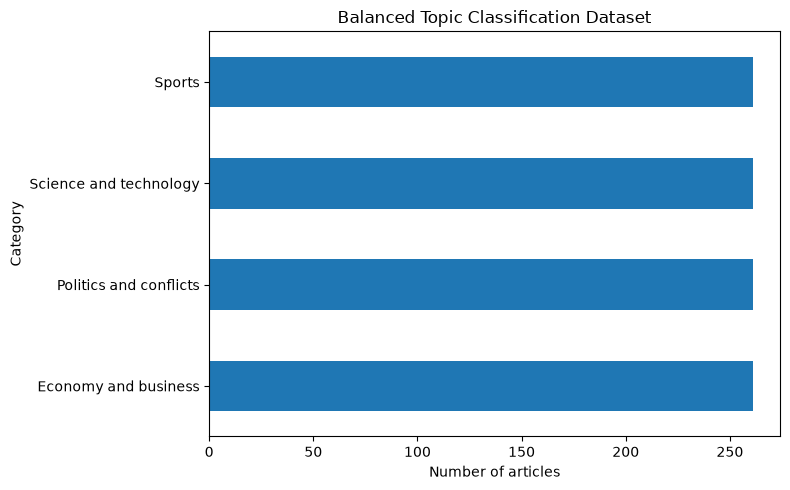

In [32]:
classification_data[
    "primary_category"
].value_counts().sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Balanced Topic Classification Dataset",
)

plt.xlabel("Number of articles")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## Key Findings

- The WikiNews dataset contains 15,200 multilingual records.
- English is the largest language subset with 5,240 articles.
- Four news categories were selected: Politics and conflicts, Economy and business, Science and technology, and Sports.
- Some articles belong to multiple selected categories, so exclusive single-label articles are used for cleaner classification.
- The exclusive-category dataset contains 3,261 articles.
- After applying article-quality filters, 3,138 articles remain suitable for detailed NLP analysis.
- A balanced sample of 60 articles was selected for NER, summarization, and similarity analysis.
- A balanced dataset of 1,044 articles was prepared for topic classification, with 261 articles per category.